# Week 3 – Appropriate Feature Engineering for the Updated Retail Dataset

## Objective

The updated retail dataset is primarily a **structured tabular dataset** with business, pricing, promotion, customer, store, and supply-chain variables.

Therefore, the most appropriate feature engineering methods for this dataset are:

1. **Categorical Encoding**
2. **Date and Calendar-Based Features**
3. **Lag Features**
4. **Rolling Statistics**
5. **Price and Promotion Interaction Features**
6. **Store / Product Aggregation Features**
7. **Scaling and PCA for Numeric Feature Groups**

These methods are better aligned with **retail demand forecasting** than NLP-heavy vectorization methods, because most fields in this dataset are short labels or structured business attributes rather than long free-text documents.

## Important Rule

As required in the project, **no original features will be dropped**.  
All new features will be added as additional engineered variables.

## Load the Updated Dataset

We begin by loading the updated dataset and converting relevant date columns into proper datetime format.

This step is necessary because many useful retail forecasting features depend on time and event patterns.

In [111]:
# @title Import required libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Display settings for easier reading
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# Load the updated retail dataset
df = pd.read_csv("/content/master_retail_dataset_v2.csv")

# Convert date columns to datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Launch_Date"] = pd.to_datetime(df["Launch_Date"], errors="coerce")

# Show basic information
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 58)


,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,Current_Price,Store_ID,Store_Type,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold,Festival_Name,Festival_Type,UPC_EAN,Product_Name,Sub_Category,Brand_Name,Brand_Tier,Shelf_Life_Days,No_of_Checkout_Counters,Avg_Billing_Time_min,Local_Population_Density,Product_Age_Days,No_of_Customer_Purchases,Unit_Cost,Promotional_Campaign_Flag,Competitor_Promotion_Flag,Google_Trends_Current_Wk,Google_Trends_Lag_1w,Shelf_Capacity,Promotion_Type,Marketing_Spend,Payday_Flag,School_Vacation_Flag,Local_Event_Flag,Launch_Date,Seasonal_Product_Flag,Online_Sales_Units,In_Store_Sales_Units,App_Traffic_Index,Website_Visits,Backorder_Flag,Supplier_Delay_Days,Fill_Rate_Pct,Loyalty_Program_Usage_Count,Repeat_Purchase_Rate,Avg_Basket_Size
0,2023-04-13,3,4,2023,0,0,1002,Grocery,410.09,0.01,405.99,15,Urban,411.58,127.6,29.1,8.5,0.63,7,141,471,83,NaN,NaN,8148570840155,Nestle Beverages 1002,Beverages,Nestle,Premium,54,6,5.9,12371,228,22,322.20,N,N,32,32,30,NaN,1247,0,0,0,2022-08-28,Y,12,71,488,896,N,0,88.93,11,0.14,3.77
1,2023-12-15,4,12,2023,0,0,1014,Home,89.98,0.30,62.99,7,Rural,90.37,56.9,1.9,5.3,0.35,11,59,263,102,NaN,NaN,7203826864190,Tupperware Decor 1014,Decor,Tupperware,Budget,2244,11,5.2,1046,1822,69,47.96,Y,Y,77,32,99,Flash Sale,1942,0,1,0,2018-12-19,Y,31,71,619,1406,N,2,90.16,31,0.14,1.48
2,2023-09-28,3,9,2023,0,0,1015,Electronics,404.88,0.14,348.20,17,Urban,408.07,191.8,14.5,2.8,0.77,4,111,302,89,NaN,NaN,5094762337870,Sony Computers 1015,Computers,Sony,Mid,1196,11,7.4,9278,1759,83,319.44,N,Y,19,77,71,NaN,1042,0,0,0,2018-12-04,N,32,57,626,1432,N,6,88.00,23,0.38,1.07
3,2023-04-17,0,4,2023,0,0,1012,Grocery,347.97,0.43,198.34,12,Urban,349.20,71.6,24.4,1.3,0.86,11,38,389,98,NaN,NaN,16104203210,Nestle Spices 1012,Spices,Nestle,Premium,7,8,4.4,7650,1330,21,266.76,Y,N,33,19,28,Flash Sale,4105,0,0,0,2019-08-26,N,32,66,626,1432,N,2,91.17,7,0.13,4.67
4,2023-03-13,0,3,2023,0,0,1016,Grocery,280.16,0.14,240.94,18,Urban,252.64,185.5,26.0,0.4,0.36,14,46,262,100,NaN,NaN,8572879201082,Tata Spices 1016,Spices,Tata,Premium,10,13,2.6,5779,1127,46,172.32,N,Y,60,33,95,NaN,706,0,0,0,2020-02-10,N,23,77,564,1191,N,0,89.39,9,0.16,2.17


In [112]:
# ------------------------------------------------------------
# @title Convert required columns to numeric before feature engineering
# ------------------------------------------------------------

# Some columns may be stored as text (object) even though they look numeric.
# We convert them safely using pd.to_numeric().
# errors="coerce" will replace invalid text values with NaN.

numeric_conversion_cols = [
    "Discount_Percentage",
    "Base_Price",
    "Current_Price",
    "Competitor_Price",
    "Online_Sales_Units",
    "In_Store_Sales_Units",
    "Supplier_Delay_Days",
    "Lead_Time_Days",
    "Loyalty_Program_Usage_Count",
    "Repeat_Purchase_Rate",
    "Avg_Basket_Size",
    "Marketing_Spend",
    "Stock_On_Hand",
    "Fill_Rate_Pct"
]

for col in numeric_conversion_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# Convert binary / flag columns into numeric 0/1 form
# ------------------------------------------------------------

# Promotional_Campaign_Flag may be stored as Yes/No, True/False, Y/N, etc.
# This maps common text forms into numeric values.

if "Promotional_Campaign_Flag" in df.columns:
    df["Promotional_Campaign_Flag"] = (
        df["Promotional_Campaign_Flag"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "yes": 1, "y": 1, "true": 1, "1": 1,
            "no": 0, "n": 0, "false": 0, "0": 0
        })
    )

# Backorder_Flag may also be stored as text
if "Backorder_Flag" in df.columns:
    df["Backorder_Flag"] = (
        df["Backorder_Flag"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "yes": 1, "y": 1, "true": 1, "1": 1,
            "no": 0, "n": 0, "false": 0, "0": 0
        })
    )

# If there are still missing values after mapping/conversion, fill them
fill_zero_cols = [
    "Promotional_Campaign_Flag",
    "Backorder_Flag",
    "Discount_Percentage",
    "Base_Price",
    "Current_Price",
    "Competitor_Price",
    "Online_Sales_Units",
    "In_Store_Sales_Units",
    "Supplier_Delay_Days",
    "Lead_Time_Days",
    "Loyalty_Program_Usage_Count",
    "Repeat_Purchase_Rate",
    "Avg_Basket_Size",
    "Marketing_Spend",
    "Stock_On_Hand",
    "Fill_Rate_Pct"
]

for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Check result
print(df[fill_zero_cols].dtypes)

Promotional_Campaign_Flag        int64
Backorder_Flag                   int64
Discount_Percentage            float64
Base_Price                     float64
Current_Price                  float64
Competitor_Price               float64
Online_Sales_Units               int64
In_Store_Sales_Units             int64
Supplier_Delay_Days              int64
Lead_Time_Days                   int64
Loyalty_Program_Usage_Count      int64
Repeat_Purchase_Rate           float64
Avg_Basket_Size                float64
Marketing_Spend                  int64
Stock_On_Hand                    int64
Fill_Rate_Pct                  float64
dtype: object


## Identify Important Feature Groups

Before feature engineering, we identify which columns are:

- categorical / label-like
- numeric
- date-based

This helps us choose the right transformation method for each type of feature.

In [113]:
# @title Identify categorical and numeric columns automatically
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("\nNumber of numeric columns:", len(numeric_cols))

Categorical columns:
['Category', 'Store_Type', 'Festival_Name', 'Festival_Type', 'Product_Name', 'Sub_Category', 'Brand_Name', 'Brand_Tier', 'Competitor_Promotion_Flag', 'Promotion_Type', 'Seasonal_Product_Flag']

Number of categorical columns: 11

Number of numeric columns: 45


# 1. Categorical Encoding

## Why Categorical Encoding Is Needed

Many important retail variables are categorical, such as:

- `Category`
- `Store_Type`
- `Festival_Name`
- `Festival_Type`
- `Product_Name`
- `Sub_Category`
- `Brand_Name`
- `Brand_Tier`
- `Promotion_Type`

Machine learning models cannot directly process text labels, so these categories must be converted into numerical features.

## Encoding Strategy

We use two approaches:

### A. One-Hot Encoding
Used for **low-cardinality** columns, where the number of unique values is small.

Examples:
- `Store_Type`
- `Brand_Tier`
- `Festival_Type`
- `Promotion_Type`

### B. Frequency Encoding
Used for **high-cardinality** columns, where the number of unique values is large.

Examples:
- `Product_Name`
- `Brand_Name`
- `Festival_Name`

This helps avoid creating too many dummy columns.

In [114]:
# @title Select some low-cardinality and high-cardinality categorical columns manually
low_cardinality_cols = [
    "Store_Type",
    "Brand_Tier",
    "Festival_Type",
    "Promotion_Type",
    "Category",
    "Sub_Category"
]

high_cardinality_cols = [
    "Product_Name",
    "Brand_Name",
    "Festival_Name",
    "Product_ID",
    "Store_ID",
    "UPC_EAN"
]

# Fill missing values with a placeholder
for col in low_cardinality_cols + high_cardinality_cols:
    df[col] = df[col].fillna("Unknown")



In [115]:
# -------------------------------
# @title A. One-Hot Encoding
# -------------------------------
# This creates binary columns such as Store_Type_Mall, Store_Type_Urban, etc.
one_hot_df = pd.get_dummies(df[low_cardinality_cols], prefix=low_cardinality_cols)

print("One-hot encoded shape:", one_hot_df.shape)
one_hot_df.head()

One-hot encoded shape: (2000, 39)


,Store_Type_Rural,Store_Type_Urban,Brand_Tier_Budget,Brand_Tier_Mid,Brand_Tier_Premium,Festival_Type_Gifting Season,Festival_Type_Mega Festive,Festival_Type_Unknown,Festival_Type_Wedding Season,Promotion_Type_BOGO,Promotion_Type_Flash Sale,Promotion_Type_Loyalty Only,Promotion_Type_Seasonal Discount,Promotion_Type_Unknown,Category_Beauty,Category_Clothing,Category_Electronics,Category_Grocery,Category_Home,Sub_Category_Accessories,Sub_Category_Activewear,Sub_Category_Audio,Sub_Category_Bedding,Sub_Category_Beverages,Sub_Category_Computers,Sub_Category_Dairy,Sub_Category_Decor,Sub_Category_Ethnic wear,Sub_Category_Formalwear,Sub_Category_Fragrance,Sub_Category_Furniture,Sub_Category_Grains,Sub_Category_Haircare,Sub_Category_Kitchenware,Sub_Category_Makeup,Sub_Category_Mobiles,Sub_Category_Skincare,Sub_Category_Spices,Sub_Category_Winter wear
0,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [116]:
# -------------------------------
# @title B. Frequency Encoding
# -------------------------------
# This replaces each category with how often it appears in the dataset
for col in high_cardinality_cols:
    freq_map = df[col].value_counts(normalize=True)
    df[f"{col}_freq_enc"] = df[col].map(freq_map)

# Preview new frequency-encoded columns
freq_encoded_cols = [f"{col}_freq_enc" for col in high_cardinality_cols]
df[freq_encoded_cols].head()

,Product_Name_freq_enc,Brand_Name_freq_enc,Festival_Name_freq_enc,Product_ID_freq_enc,Store_ID_freq_enc,UPC_EAN_freq_enc
0,0.0115,0.0585,0.9725,0.0495,0.0570,0.0115
1,0.0100,0.0710,0.9725,0.0560,0.0565,0.0100
2,0.0130,0.0625,0.9725,0.0565,0.0540,0.0130
3,0.0095,0.0585,0.9725,0.0595,0.0475,0.0095
4,0.0120,0.0610,0.9725,0.0570,0.0590,0.0120


## Observation

The categorical encoding step worked as expected.

- One-Hot Encoding produced **39 binary columns** from the selected low-cardinality features.
- Frequency Encoding added compact numeric representations for high-cardinality fields such as `Product_Name`, `Brand_Name`, `Festival_Name`, `Product_ID`, `Store_ID`, and `UPC_EAN`.

The preview shows that some encoded categories are very common. For example, the displayed `Festival_Name_freq_enc` value of **0.9725** indicates that one festival label dominates most rows. This suggests that some categorical fields may contribute limited additional variation, while others such as product and brand identifiers are likely to be more informative.

Overall, this encoding strategy is appropriate for a structured retail dataset because it preserves business labels in numerical form without creating an excessively large feature space.

# 2. Date and Calendar-Based Features

## Why Calendar Features Matter

Retail demand often changes with:

- day of week
- month or quarter
- weekend patterns
- paydays
- school vacations
- festivals and local events

These time-based effects are important in demand forecasting.

## Engineered Calendar Features

From the `Date` column, we create:

- day of month
- week of year
- quarter
- month start flag
- month end flag
- season
- days since launch

In [117]:
# Create calendar-based features from the main Date column
df["Day_of_Month"] = df["Date"].dt.day
df["Week_of_Year"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["Is_Month_Start"] = df["Date"].dt.is_month_start.astype(int)
df["Is_Month_End"] = df["Date"].dt.is_month_end.astype(int)

# Create season from month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)

# Create days since product launch
df["Days_Since_Launch"] = (df["Date"] - df["Launch_Date"]).dt.days

# Replace negative or missing values if any
df["Days_Since_Launch"] = df["Days_Since_Launch"].fillna(0).clip(lower=0)

# Preview engineered calendar columns
calendar_cols = [
    "Day_of_Month", "Week_of_Year", "Quarter",
    "Is_Month_Start", "Is_Month_End", "Season", "Days_Since_Launch"
]

df[calendar_cols].head()

,Day_of_Month,Week_of_Year,Quarter,Is_Month_Start,Is_Month_End,Season,Days_Since_Launch
0,13,15,2,0,0,Spring,228
1,15,50,4,0,0,Winter,1822
2,28,39,3,0,0,Fall,1759
3,17,16,2,0,0,Spring,1330
4,13,11,1,0,0,Spring,1127


## Observation

The calendar feature engineering step successfully added interpretable time-based variables such as:

- `Day_of_Month`
- `Week_of_Year`
- `Quarter`
- `Is_Month_Start`
- `Is_Month_End`
- `Season`
- `Days_Since_Launch`

The preview confirms that dates span multiple parts of the year, with examples from **Spring, Fall, and Winter**, and that `Days_Since_Launch` was computed correctly from the product launch date.

These features are useful because retail demand often depends on seasonality, launch timing, and calendar effects rather than only product and price variables.

## Prepare Data for Lag and Rolling Features

Lag and rolling features depend on the time order of observations.

So we sort the dataset by:
- `Store_ID`
- `Product_ID`
- `Date`

This ensures that previous records are correctly aligned before generating lag-based demand features.

In [118]:
# Sort data before creating lag and rolling features
df = df.sort_values(by=["Store_ID", "Product_ID", "Date"]).reset_index(drop=True)

# Check sorted output
df[["Store_ID", "Product_ID", "Date", "Daily_Units_Sold"]].head(10)

,Store_ID,Product_ID,Date,Daily_Units_Sold
0,1,1000,2023-03-29,87
1,1,1000,2023-06-13,104
2,1,1000,2023-11-15,92
3,1,1001,2023-04-08,98
4,1,1001,2023-06-11,98
5,1,1001,2023-07-23,114
6,1,1001,2023-09-19,102
7,1,1001,2023-10-30,114
8,1,1001,2023-11-16,107
9,1,1001,2023-12-01,120


# 3. Lag Features

## Why Lag Features Are Important

In demand forecasting, previous sales often help predict future sales.

Lag features capture the value of a variable from earlier time periods.

Examples:
- previous day sales
- previous 7-day sales
- previous 14-day sales

## Formula

For a lag of $k$ periods:

$
\text{Lag}_k(t) = y_{t-k}
$

where:
- $y_t$ = target value at time $t$
- $y_{t-k}$ = target value from $k$ periods earlier

In [119]:
# Create lag features for Daily_Units_Sold within each Store_ID + Product_ID group
group_cols = ["Store_ID", "Product_ID"]

df["lag_1_sales"] = df.groupby(group_cols)["Daily_Units_Sold"].shift(1)
df["lag_7_sales"] = df.groupby(group_cols)["Daily_Units_Sold"].shift(7)
df["lag_14_sales"] = df.groupby(group_cols)["Daily_Units_Sold"].shift(14)

# Preview lag features
df[["Store_ID", "Product_ID", "Date", "Daily_Units_Sold", "lag_1_sales", "lag_7_sales", "lag_14_sales"]].head(15)

,Store_ID,Product_ID,Date,Daily_Units_Sold,lag_1_sales,lag_7_sales,lag_14_sales
0,1,1000,2023-03-29,87,NaN,NaN,NaN
1,1,1000,2023-06-13,104,87.0,NaN,NaN
2,1,1000,2023-11-15,92,104.0,NaN,NaN
3,1,1001,2023-04-08,98,NaN,NaN,NaN
4,1,1001,2023-06-11,98,98.0,NaN,NaN
5,1,1001,2023-07-23,114,98.0,NaN,NaN
6,1,1001,2023-09-19,102,114.0,NaN,NaN
7,1,1001,2023-10-30,114,102.0,NaN,NaN
8,1,1001,2023-11-16,107,114.0,NaN,NaN
9,1,1001,2023-12-01,120,107.0,NaN,NaN


## Observation

The lag feature generation step worked correctly.

- `lag_1_sales` contains the immediately previous sales value within each `Store_ID` and `Product_ID` group.
- The first record in each product-store sequence contains `NaN`, which is expected because there is no previous history available.
- Because many product-store combinations have only a small number of observations, longer lag features such as `lag_14_sales` may contain a large number of missing values.

This confirms that lag features are correctly capturing historical demand, but it also shows that sparse time series history can limit the usefulness of longer lags in this dataset.

# 4. Rolling Statistics

## Why Rolling Features Matter

Rolling statistics summarize recent demand behavior over a moving window.

This helps capture:
- short-term trend
- local demand momentum
- volatility

## Common Rolling Features

- rolling mean
- rolling standard deviation
- rolling minimum / maximum

In [120]:
# Create rolling statistics for demand within each Store_ID + Product_ID group
df["rolling_mean_7"] = (
    df.groupby(group_cols)["Daily_Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

df["rolling_std_7"] = (
    df.groupby(group_cols)["Daily_Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).std())
)

df["rolling_mean_30"] = (
    df.groupby(group_cols)["Daily_Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)

# Preview rolling statistics
df[[
    "Store_ID", "Product_ID", "Date", "Daily_Units_Sold",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_30"
]].head(15)

,Store_ID,Product_ID,Date,Daily_Units_Sold,rolling_mean_7,rolling_std_7,rolling_mean_30
0,1,1000,2023-03-29,87,NaN,NaN,NaN
1,1,1000,2023-06-13,104,87.000000,NaN,87.000000
2,1,1000,2023-11-15,92,95.500000,12.020815,95.500000
3,1,1001,2023-04-08,98,NaN,NaN,NaN
4,1,1001,2023-06-11,98,98.000000,NaN,98.000000
5,1,1001,2023-07-23,114,98.000000,0.000000,98.000000
6,1,1001,2023-09-19,102,103.333333,9.237604,103.333333
7,1,1001,2023-10-30,114,103.000000,7.571878,103.000000
8,1,1001,2023-11-16,107,105.200000,8.197561,105.200000
9,1,1001,2023-12-01,120,105.500000,7.368853,105.500000


## Observation

The rolling statistics were generated successfully.

- `rolling_mean_7` begins after the first available observation in each product-store group.
- The first row in each sequence is `NaN`, which is expected because there is no prior history to summarize.
- Subsequent rows show sensible smoothed values, such as moving from a single prior value to an average across multiple earlier sales points.

These features provide a more stable view of recent demand than a single lag value and are therefore useful for forecasting short-term retail sales patterns.

# 5. Price and Promotion Interaction Features

## Why Interaction Features Matter

Retail demand is often influenced by combinations of variables rather than individual variables alone.

Examples:
- price relative to competitor
- discount combined with promotion
- promotion during a festival
- online vs in-store sales balance

These interaction features help capture real-world retail effects more accurately.

In [121]:
# ------------------------------------------------------------
# @title Create price and promotion interaction features
# ------------------------------------------------------------

# Absolute discount amount
df["Discount_Amount"] = df["Base_Price"] - df["Current_Price"]

# Price gap with competitor
df["Price_Gap_Competitor"] = df["Current_Price"] - df["Competitor_Price"]

# Price ratio compared to competitor
df["Price_Ratio_Competitor"] = df["Current_Price"] / (df["Competitor_Price"] + 1e-6)

# Promotion x discount interaction
df["Promo_Discount_Interaction"] = df["Promotional_Campaign_Flag"] * df["Discount_Percentage"]

# Promotion x festival interaction
df["Promo_Festival_Interaction"] = df["Promotional_Campaign_Flag"] * df["Is_Holiday"]

# Online sales share
df["Online_Sales_Share"] = df["Online_Sales_Units"] / (
    df["Online_Sales_Units"] + df["In_Store_Sales_Units"] + 1e-6
)

# Preview
interaction_cols = [
    "Discount_Amount",
    "Price_Gap_Competitor",
    "Price_Ratio_Competitor",
    "Promo_Discount_Interaction",
    "Promo_Festival_Interaction",
    "Online_Sales_Share"
]

df[interaction_cols].head()

,Discount_Amount,Price_Gap_Competitor,Price_Ratio_Competitor,Promo_Discount_Interaction,Promo_Festival_Interaction,Online_Sales_Share
0,164.74,-139.88,0.628916,0.41,0,0.137931
1,91.23,-86.85,0.621635,0.39,0,0.240385
2,15.45,-16.30,0.915949,0.00,0,0.239130
3,55.31,-48.28,0.857447,0.16,0,0.357143
4,48.73,-55.23,0.866135,0.00,0,0.265306


## Observation

The interaction features were created successfully and show meaningful variation.

The preview confirms that the engineered variables capture different retail relationships:

- `Discount_Amount` varies substantially across rows.
- `Price_Gap_Competitor` is negative in the displayed examples, indicating that the current price is lower than the competitor price for those records.
- `Price_Ratio_Competitor` values below **1.0** support the same interpretation.
- `Promo_Discount_Interaction`, `Promo_Festival_Interaction`, and `Online_Sales_Share` provide combined business signals rather than isolated variables.

These interaction features are valuable because retail demand is often driven by combinations such as price position, promotion intensity, and online/offline channel behavior.

# 6. Store / Product Aggregation Features

## Why Aggregation Features Are Useful

Retail datasets often contain repeated demand patterns at different levels, such as:

- store-level demand
- product-level demand
- category-level demand
- brand-level demand

Aggregated features capture these broader patterns and provide the model with more context.

In [122]:
# Create aggregated mean sales features
df["Avg_Sales_By_Store"] = df.groupby("Store_ID")["Daily_Units_Sold"].transform("mean")
df["Avg_Sales_By_Product"] = df.groupby("Product_ID")["Daily_Units_Sold"].transform("mean")
df["Avg_Sales_By_Category"] = df.groupby("Category")["Daily_Units_Sold"].transform("mean")
df["Avg_Sales_By_Brand"] = df.groupby("Brand_Name")["Daily_Units_Sold"].transform("mean")
df["Avg_Footfall_By_Store"] = df.groupby("Store_ID")["Footfall_Index"].transform("mean")

# Preview aggregated features
agg_cols = [
    "Avg_Sales_By_Store",
    "Avg_Sales_By_Product",
    "Avg_Sales_By_Category",
    "Avg_Sales_By_Brand",
    "Avg_Footfall_By_Store"
]

df[agg_cols].head()

,Avg_Sales_By_Store,Avg_Sales_By_Product,Avg_Sales_By_Category,Avg_Sales_By_Brand,Avg_Footfall_By_Store
0,113.326531,114.493976,113.404977,113.079545,122.428571
1,113.326531,114.493976,110.687339,109.856000,122.428571
2,113.326531,114.493976,113.256614,119.402062,122.428571
3,113.326531,109.446809,113.404977,113.672131,122.428571
4,113.326531,109.446809,111.590793,114.626761,122.428571


## Observation

The aggregation features were created successfully and add useful business context.

The preview shows:

- `Avg_Sales_By_Store` values around **113 units**, suggesting relatively stable store-level average demand in the sample shown.
- `Avg_Sales_By_Product`, `Avg_Sales_By_Category`, and `Avg_Sales_By_Brand` vary across rows, which means these features capture persistent differences across products, categories, and brands.
- `Avg_Footfall_By_Store` adds store-level customer traffic context that can support demand estimation.

These features help the model learn broader demand patterns beyond individual row-level observations.

# 7. Customer and Supply-Chain Derived Features

## Why These Features Matter

The updated dataset already contains customer and supply-chain information.

We can derive additional features such as:

- stock coverage
- delay-adjusted supply signal
- loyalty intensity
- repeat-purchase influence

These help connect forecasting with inventory and customer behavior.

In [123]:
# ------------------------------------------------------------
# @title Create customer and supply-chain derived features
# ------------------------------------------------------------

# Estimated stock coverage in days
df["Stock_Coverage_Ratio"] = df["Stock_On_Hand"] / (df["rolling_mean_7"] + 1e-6)

# Supply risk score
df["Supply_Risk_Score"] = df["Backorder_Flag"] + (
    df["Supplier_Delay_Days"] / (df["Lead_Time_Days"] + 1e-6)
)

# Customer engagement index
df["Customer_Engagement_Index"] = (
    df["Loyalty_Program_Usage_Count"] * 0.5
    + df["Repeat_Purchase_Rate"] * 0.3
    + df["Avg_Basket_Size"] * 0.2
)

# Preview
derived_cols = [
    "Stock_Coverage_Ratio",
    "Supply_Risk_Score",
    "Customer_Engagement_Index"
]

df[derived_cols].head()

,Stock_Coverage_Ratio,Supply_Risk_Score,Customer_Engagement_Index
0,NaN,0.076923,7.349
1,3.436782,0.555555,11.959
2,1.623037,0.214286,5.456
3,NaN,0.000000,3.149
4,0.928571,0.333333,9.232


## Observation

The customer and supply-chain derived features were generated successfully.

The preview shows:

- `Stock_Coverage_Ratio` is missing for some rows because it depends on `rolling_mean_7`, which is not available at the beginning of a sequence.
- `Supply_Risk_Score` varies across records, indicating different levels of replenishment or backorder-related risk.
- `Customer_Engagement_Index` also varies across rows, reflecting differences in loyalty usage, repeat purchasing, and basket size.

These features are useful because they connect demand forecasting with operational risk and customer behavior rather than relying only on pricing and sales history.

## Encode the Season Feature

Since `Season` is categorical, we convert it to dummy variables using one-hot encoding.

In [124]:
# One-hot encode the Season column
season_df = pd.get_dummies(df["Season"], prefix="Season")

print("Season dummy shape:", season_df.shape)
season_df.head()

Season dummy shape: (2000, 4)


,Season_Fall,Season_Spring,Season_Summer,Season_Winter
0,False,True,False,False
1,False,False,True,False
2,True,False,False,False
3,False,True,False,False
4,False,False,True,False


# 8. Standardization for Numeric Feature Groups

## Why Standardization Is Needed

Standardization transforms a variable so that:

- mean = 0
- standard deviation = 1

This is useful before:
- PCA
- linear regression
- regularized models

Tree-based models such as Random Forest usually do not require scaling, but PCA does.

In [125]:
# ------------------------------------------------------------
# @title Create customer and supply-chain derived features
# ------------------------------------------------------------

# Estimated stock coverage in days
df["Stock_Coverage_Ratio"] = df["Stock_On_Hand"] / (df["rolling_mean_7"] + 1e-6)

# Supply risk score
df["Supply_Risk_Score"] = df["Backorder_Flag"] + (
    df["Supplier_Delay_Days"] / (df["Lead_Time_Days"] + 1e-6)
)

# Customer engagement index
df["Customer_Engagement_Index"] = (
    df["Loyalty_Program_Usage_Count"] * 0.5
    + df["Repeat_Purchase_Rate"] * 0.3
    + df["Avg_Basket_Size"] * 0.2
)

# Preview
derived_cols = [
    "Stock_Coverage_Ratio",
    "Supply_Risk_Score",
    "Customer_Engagement_Index"
]

df[derived_cols].head()

,Stock_Coverage_Ratio,Supply_Risk_Score,Customer_Engagement_Index
0,NaN,0.076923,7.349
1,3.436782,0.555555,11.959
2,1.623037,0.214286,5.456
3,NaN,0.000000,3.149
4,0.928571,0.333333,9.232


In [126]:
# @title Select a subset of numeric features for scaling
pca_candidate_cols = [
    "Base_Price", "Discount_Percentage", "Current_Price", "Competitor_Price",
    "Footfall_Index", "Avg_Temperature", "Rainfall_mm",
    "Lead_Time_Days", "Safety_Stock_Level", "Stock_On_Hand",
    "Marketing_Spend", "Supplier_Delay_Days", "Fill_Rate_Pct",
    "Loyalty_Program_Usage_Count", "Repeat_Purchase_Rate", "Avg_Basket_Size",
    "Discount_Amount", "Price_Gap_Competitor", "Price_Ratio_Competitor",
    "Stock_Coverage_Ratio", "Supply_Risk_Score", "Customer_Engagement_Index"
]

# Keep only columns that actually exist in the dataframe
available_pca_cols = [col for col in pca_candidate_cols if col in df.columns]
missing_pca_cols = [col for col in pca_candidate_cols if col not in df.columns]

print("Available PCA columns:", available_pca_cols)
print("Missing PCA columns:", missing_pca_cols)

# Fill missing values before scaling
scaled_input = df[available_pca_cols].fillna(0)

# Standardize
scaler = StandardScaler()
scaled_array = scaler.fit_transform(scaled_input)

scaled_df = pd.DataFrame(
    scaled_array,
    columns=[f"scaled_{col}" for col in available_pca_cols]
)

scaled_df.head()

Available PCA columns: ['Base_Price', 'Discount_Percentage', 'Current_Price', 'Competitor_Price', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'Marketing_Spend', 'Supplier_Delay_Days', 'Fill_Rate_Pct', 'Loyalty_Program_Usage_Count', 'Repeat_Purchase_Rate', 'Avg_Basket_Size', 'Discount_Amount', 'Price_Gap_Competitor', 'Price_Ratio_Competitor', 'Stock_Coverage_Ratio', 'Supply_Risk_Score', 'Customer_Engagement_Index']
Missing PCA columns: []


,scaled_Base_Price,scaled_Discount_Percentage,scaled_Current_Price,scaled_Competitor_Price,scaled_Footfall_Index,scaled_Avg_Temperature,scaled_Rainfall_mm,scaled_Lead_Time_Days,scaled_Safety_Stock_Level,scaled_Stock_On_Hand,scaled_Marketing_Spend,scaled_Supplier_Delay_Days,scaled_Fill_Rate_Pct,scaled_Loyalty_Program_Usage_Count,scaled_Repeat_Purchase_Rate,scaled_Avg_Basket_Size,scaled_Discount_Amount,scaled_Price_Gap_Competitor,scaled_Price_Ratio_Competitor,scaled_Stock_Coverage_Ratio,scaled_Supply_Risk_Score,scaled_Customer_Engagement_Index
0,1.092642,1.145533,0.449673,0.909292,-1.775003,1.642824,0.458930,1.325188,1.383262,1.040909,-0.456551,-0.558507,-0.937789,-0.792916,-0.441949,-0.590011,1.947539,-1.400087,-0.844686,-1.148304,-0.606897,-0.822477
1,-0.091524,1.004091,-0.376374,-0.121883,1.165328,1.002296,0.401091,0.309913,-0.497547,0.316801,0.954558,1.833385,-1.135368,-0.219908,0.477102,-0.163003,0.564802,-0.455582,-0.893818,0.959782,0.033011,-0.226064
2,-0.379578,-1.188248,-0.070567,-0.370985,0.240148,0.699344,-0.196574,1.579007,-1.173178,-0.666893,-1.069232,0.637439,1.529600,-1.111253,-1.475881,2.557932,-0.860633,0.800969,1.091997,-0.152750,-0.423250,-1.067381
3,0.696956,-0.622483,0.916436,0.641583,-0.501409,-0.062365,-0.061617,0.563732,1.511084,1.259507,0.813724,-1.156479,0.365294,-1.429591,1.625916,3.114036,-0.110859,0.231380,0.697266,-1.148304,-0.709739,-1.365846
4,1.122760,-0.905365,1.502406,1.158534,-0.138870,-1.706964,-0.967755,-0.451544,0.798933,-1.104090,-0.898458,0.039466,0.393519,-0.601913,1.740798,1.028648,-0.234630,0.107595,0.755889,-0.578728,-0.264089,-0.578866


# 9. PCA on Numeric Feature Groups

## Why PCA Is Applied

PCA helps reduce redundancy among correlated numeric features and creates compact high-variance components.

In this project:
- original features are **not removed**
- PCA components are added as **new engineered features**

This helps preserve interpretability while also capturing latent patterns.

In [127]:
# Apply PCA to the standardized numeric subset
pca = PCA(n_components=3)

pca_components = pca.fit_transform(scaled_array)

# Add PCA components to the dataset
df["PCA_Num_1"] = pca_components[:, 0]
df["PCA_Num_2"] = pca_components[:, 1]
df["PCA_Num_3"] = pca_components[:, 2]

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)

# Preview PCA columns
df[["PCA_Num_1", "PCA_Num_2", "PCA_Num_3"]].head()

Explained variance ratio: [0.19772961 0.14989936 0.09113731]


,PCA_Num_1,PCA_Num_2,PCA_Num_3
0,3.067458,0.662383,0.410049
1,0.731407,1.532137,0.658702
2,-0.842070,-2.767932,1.875673
3,1.547695,-2.288864,2.160511
4,1.279122,-2.433340,-0.722770


## Observation

PCA was applied successfully to the selected numeric feature group.

The first three principal components explain approximately:

- **19.77%** of the variance in Component 1
- **14.99%** of the variance in Component 2
- **9.11%** of the variance in Component 3

Together, the first three components explain about **43.88%** of the total variance.

This indicates that the numeric feature set contains substantial shared structure, but the variance is distributed across multiple dimensions rather than being dominated by only one component. Therefore, PCA is useful here as an additional compact representation, but it should complement rather than replace the original engineered variables.

# Combine Engineered Features

At this stage, we have created multiple new feature groups:

- one-hot encoded categorical features
- frequency encoded categorical features
- calendar features
- lag features
- rolling statistics
- interaction features
- aggregation features
- season dummy variables
- PCA components

These can later be combined into a final modeling dataset.

In [128]:
# Concatenate selected engineered feature blocks
engineered_feature_df = pd.concat(
    [
        df,
        one_hot_df,
        season_df,
        scaled_df
    ],
    axis=1
)

print("Final engineered dataset shape:", engineered_feature_df.shape)
engineered_feature_df.head()

Final engineered dataset shape: (2000, 159)


,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,Current_Price,Store_ID,Store_Type,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold,Festival_Name,Festival_Type,UPC_EAN,Product_Name,Sub_Category,Brand_Name,Brand_Tier,Shelf_Life_Days,No_of_Checkout_Counters,Avg_Billing_Time_min,Local_Population_Density,Product_Age_Days,No_of_Customer_Purchases,Unit_Cost,Promotional_Campaign_Flag,Competitor_Promotion_Flag,Google_Trends_Current_Wk,Google_Trends_Lag_1w,Shelf_Capacity,Promotion_Type,Marketing_Spend,Payday_Flag,School_Vacation_Flag,Local_Event_Flag,Launch_Date,Seasonal_Product_Flag,Online_Sales_Units,In_Store_Sales_Units,App_Traffic_Index,Website_Visits,Backorder_Flag,Supplier_Delay_Days,Fill_Rate_Pct,Loyalty_Program_Usage_Count,Repeat_Purchase_Rate,Avg_Basket_Size,Product_Name_freq_enc,Brand_Name_freq_enc,Festival_Name_freq_enc,Product_ID_freq_enc,Store_ID_freq_enc,UPC_EAN_freq_enc,Day_of_Month,Week_of_Year,Quarter,Is_Month_Start,Is_Month_End,Season,Days_Since_Launch,lag_1_sales,lag_7_sales,lag_14_sales,rolling_mean_7,rolling_std_7,rolling_mean_30,Discount_Amount,Price_Gap_Competitor,Price_Ratio_Competitor,Promo_Discount_Interaction,Promo_Festival_Interaction,Online_Sales_Share,Avg_Sales_By_Store,Avg_Sales_By_Product,Avg_Sales_By_Category,Avg_Sales_By_Brand,Avg_Footfall_By_Store,Stock_Coverage_Ratio,Supply_Risk_Score,Customer_Engagement_Index,PCA_Num_1,PCA_Num_2,PCA_Num_3,Store_Type_Rural,Store_Type_Urban,Brand_Tier_Budget,Brand_Tier_Mid,Brand_Tier_Premium,Festival_Type_Gifting Season,Festival_Type_Mega Festive,Festival_Type_Unknown,Festival_Type_Wedding Season,Promotion_Type_BOGO,Promotion_Type_Flash Sale,Promotion_Type_Loyalty Only,Promotion_Type_Seasonal Discount,Promotion_Type_Unknown,Category_Beauty,Category_Clothing,Category_Electronics,Category_Grocery,Category_Home,Sub_Category_Accessories,Sub_Category_Activewear,Sub_Category_Audio,Sub_Category_Bedding,Sub_Category_Beverages,Sub_Category_Computers,Sub_Category_Dairy,Sub_Category_Decor,Sub_Category_Ethnic wear,Sub_Category_Formalwear,Sub_Category_Fragrance,Sub_Category_Furniture,Sub_Category_Grains,Sub_Category_Haircare,Sub_Category_Kitchenware,Sub_Category_Makeup,Sub_Category_Mobiles,Sub_Category_Skincare,Sub_Category_Spices,Sub_Category_Winter wear,Season_Fall,Season_Spring,Season_Summer,Season_Winter,scaled_Base_Price,scaled_Discount_Percentage,scaled_Current_Price,scaled_Competitor_Price,scaled_Footfall_Index,scaled_Avg_Temperature,scaled_Rainfall_mm,scaled_Lead_Time_Days,scaled_Safety_Stock_Level,scaled_Stock_On_Hand,scaled_Marketing_Spend,scaled_Supplier_Delay_Days,scaled_Fill_Rate_Pct,scaled_Loyalty_Program_Usage_Count,scaled_Repeat_Purchase_Rate,scaled_Avg_Basket_Size,scaled_Discount_Amount,scaled_Price_Gap_Competitor,scaled_Price_Ratio_Competitor,scaled_Stock_Coverage_Ratio,scaled_Supply_Risk_Score,scaled_Customer_Engagement_Index
0,2023-03-29,2,3,2023,0,0,1000,Grocery,401.81,0.41,237.07,1,Urban,376.95,51.2,34.3,7.6,0.82,13,181,405,87,Unknown,Unknown,6817973669476,Amul Spices 1000,Spices,Amul,Budget,63,9,5.5,5995,1680,61,299.58,1,Y,37,94,48,Flash Sale,2437,0,0,0,2018-08-22,N,12,75,488,896,0,1,88.46,14,0.21,1.43,0.0105,0.0440,0.9725,0.0415,0.049,0.0105,29,13,1,0,0,Spring,1680,NaN,NaN,NaN,NaN,NaN,NaN,164.74,-139.88,0.628916,0.41,0,0.137931,113.326531,114.493976,113.404977,113.079545,122.428571,NaN,0.076923,7.349,3.067458,0.662383,0.410049,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1.092642,1.145533,0.449673,0.909292,-1.775003,1.642824,0.458930,1.325188,1.383262,1.040909,-0.456551,-0.558507,-0.937789,-0.792916,-0.441949,-0.590011,1.947539,-1.400087,-0.844686,-1.148304,-0.606897,-0.822477
1,2023-06-13,1,6,2023,0,0,1000,

## Save the Engineered Dataset

The enriched dataset can now be saved and reused in later regression modeling steps.

In [129]:
# Save engineered dataset
engineered_feature_df.to_csv("master_retail_dataset_v2_engineered.csv", index=False)

print("Engineered dataset saved successfully.")

Engineered dataset saved successfully.


# Final Summary

For the updated retail dataset, the most appropriate feature engineering methods are those that reflect the tabular and business-oriented nature of the data.

## Methods Applied

1. **Categorical Encoding**
   - One-Hot Encoding for low-cardinality features
   - Frequency Encoding for high-cardinality features
   - One-Hot Encoding produced **39 new binary columns** in the selected low-cardinality set.

2. **Date and Calendar Features**
   - day, week, quarter, month start/end, season, and days since launch

3. **Lag Features**
   - previous sales values by product-store combination
   - correctly generated, with expected missing values at the beginning of each sequence

4. **Rolling Statistics**
   - rolling averages and volatility indicators based on prior sales history

5. **Interaction Features**
   - discount amount, competitor price gap, promotion interactions, and online sales share

6. **Aggregation Features**
   - average sales by store, product, category, and brand
   - average footfall by store

7. **Customer and Supply-Chain Features**
   - stock coverage ratio, supply risk score, and customer engagement index

8. **Standardization and PCA**
   - PCA generated three additional numeric components
   - the first three components explained about **43.88%** of total variance

## Practical Conclusion

These engineered features are better aligned with retail demand forecasting than NLP-heavy methods because they directly capture business, temporal, pricing, operational, and customer behavior signals present in the dataset.

## Next Step

The next logical stage is to build **regression models** using the engineered dataset.

Recommended baseline models:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor

Evaluation metrics:

- MAE
- RMSE
- R² Score

# Week 3 – Regression Modeling for Retail Demand Forecasting

## Objective

In this section, we build baseline regression models for the retail demand forecasting problem.

The target variable is:

`Daily_Units_Sold`

Since the target is numeric and continuous, this is a **regression problem**.

## Goals

1. Prepare the engineered dataset for modeling  
2. Perform train/test split  
3. Train baseline regression models  
4. Evaluate models using:
   - MAE
   - RMSE
   - R²
5. Analyze feature importance  
6. Compare model performance  

## Baseline Models

The following regression models are used as baseline models:

- Linear Regression  
- Ridge Regression  
- Lasso Regression  
- Random Forest Regressor  

These models provide a good starting point because they are interpretable, widely used, and suitable for structured retail data.

In [130]:
# Import basic libraries
import pandas as pd
import numpy as np

# Import train/test split
from sklearn.model_selection import train_test_split

# Import regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import optional plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

## Load the Engineered Dataset

We use the engineered dataset created in the previous step.

This dataset contains:

- original features
- encoded categorical variables
- calendar features
- lag features
- rolling statistics
- interaction features
- aggregation features
- PCA components

In [131]:
# Load the engineered dataset
df_model = engineered_feature_df.copy()

print("Engineered dataset shape:", df_model.shape)
df_model.head()

Engineered dataset shape: (2000, 159)


,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,Current_Price,Store_ID,Store_Type,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold,Festival_Name,Festival_Type,UPC_EAN,Product_Name,Sub_Category,Brand_Name,Brand_Tier,Shelf_Life_Days,No_of_Checkout_Counters,Avg_Billing_Time_min,Local_Population_Density,Product_Age_Days,No_of_Customer_Purchases,Unit_Cost,Promotional_Campaign_Flag,Competitor_Promotion_Flag,Google_Trends_Current_Wk,Google_Trends_Lag_1w,Shelf_Capacity,Promotion_Type,Marketing_Spend,Payday_Flag,School_Vacation_Flag,Local_Event_Flag,Launch_Date,Seasonal_Product_Flag,Online_Sales_Units,In_Store_Sales_Units,App_Traffic_Index,Website_Visits,Backorder_Flag,Supplier_Delay_Days,Fill_Rate_Pct,Loyalty_Program_Usage_Count,Repeat_Purchase_Rate,Avg_Basket_Size,Product_Name_freq_enc,Brand_Name_freq_enc,Festival_Name_freq_enc,Product_ID_freq_enc,Store_ID_freq_enc,UPC_EAN_freq_enc,Day_of_Month,Week_of_Year,Quarter,Is_Month_Start,Is_Month_End,Season,Days_Since_Launch,lag_1_sales,lag_7_sales,lag_14_sales,rolling_mean_7,rolling_std_7,rolling_mean_30,Discount_Amount,Price_Gap_Competitor,Price_Ratio_Competitor,Promo_Discount_Interaction,Promo_Festival_Interaction,Online_Sales_Share,Avg_Sales_By_Store,Avg_Sales_By_Product,Avg_Sales_By_Category,Avg_Sales_By_Brand,Avg_Footfall_By_Store,Stock_Coverage_Ratio,Supply_Risk_Score,Customer_Engagement_Index,PCA_Num_1,PCA_Num_2,PCA_Num_3,Store_Type_Rural,Store_Type_Urban,Brand_Tier_Budget,Brand_Tier_Mid,Brand_Tier_Premium,Festival_Type_Gifting Season,Festival_Type_Mega Festive,Festival_Type_Unknown,Festival_Type_Wedding Season,Promotion_Type_BOGO,Promotion_Type_Flash Sale,Promotion_Type_Loyalty Only,Promotion_Type_Seasonal Discount,Promotion_Type_Unknown,Category_Beauty,Category_Clothing,Category_Electronics,Category_Grocery,Category_Home,Sub_Category_Accessories,Sub_Category_Activewear,Sub_Category_Audio,Sub_Category_Bedding,Sub_Category_Beverages,Sub_Category_Computers,Sub_Category_Dairy,Sub_Category_Decor,Sub_Category_Ethnic wear,Sub_Category_Formalwear,Sub_Category_Fragrance,Sub_Category_Furniture,Sub_Category_Grains,Sub_Category_Haircare,Sub_Category_Kitchenware,Sub_Category_Makeup,Sub_Category_Mobiles,Sub_Category_Skincare,Sub_Category_Spices,Sub_Category_Winter wear,Season_Fall,Season_Spring,Season_Summer,Season_Winter,scaled_Base_Price,scaled_Discount_Percentage,scaled_Current_Price,scaled_Competitor_Price,scaled_Footfall_Index,scaled_Avg_Temperature,scaled_Rainfall_mm,scaled_Lead_Time_Days,scaled_Safety_Stock_Level,scaled_Stock_On_Hand,scaled_Marketing_Spend,scaled_Supplier_Delay_Days,scaled_Fill_Rate_Pct,scaled_Loyalty_Program_Usage_Count,scaled_Repeat_Purchase_Rate,scaled_Avg_Basket_Size,scaled_Discount_Amount,scaled_Price_Gap_Competitor,scaled_Price_Ratio_Competitor,scaled_Stock_Coverage_Ratio,scaled_Supply_Risk_Score,scaled_Customer_Engagement_Index
0,2023-03-29,2,3,2023,0,0,1000,Grocery,401.81,0.41,237.07,1,Urban,376.95,51.2,34.3,7.6,0.82,13,181,405,87,Unknown,Unknown,6817973669476,Amul Spices 1000,Spices,Amul,Budget,63,9,5.5,5995,1680,61,299.58,1,Y,37,94,48,Flash Sale,2437,0,0,0,2018-08-22,N,12,75,488,896,0,1,88.46,14,0.21,1.43,0.0105,0.0440,0.9725,0.0415,0.049,0.0105,29,13,1,0,0,Spring,1680,NaN,NaN,NaN,NaN,NaN,NaN,164.74,-139.88,0.628916,0.41,0,0.137931,113.326531,114.493976,113.404977,113.079545,122.428571,NaN,0.076923,7.349,3.067458,0.662383,0.410049,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1.092642,1.145533,0.449673,0.909292,-1.775003,1.642824,0.458930,1.325188,1.383262,1.040909,-0.456551,-0.558507,-0.937789,-0.792916,-0.441949,-0.590011,1.947539,-1.400087,-0.844686,-1.148304,-0.606897,-0.822477
1,2023-06-13,1,6,2023,0,0,1000,

## Check Missing Values Before Modeling

Some engineered features such as lag variables and rolling statistics may contain missing values, especially at the beginning of each time series group.

These must be handled before training regression models.

In [132]:
# Check missing values
missing_summary = df_model.isnull().sum()
missing_summary[missing_summary > 0].sort_values(ascending=False).head(20)

,0
lag_14_sales,2000
lag_7_sales,1886
rolling_std_7,787
lag_1_sales,399
rolling_mean_7,399
rolling_mean_30,399
Stock_Coverage_Ratio,399


## Handle Missing Values

For baseline modeling, missing values are filled using simple rules:

- lag and rolling features: filled with 0
- other numeric features: filled with median
- remaining object columns: dropped or ignored during numeric feature selection

This is a practical baseline strategy for modeling.

In [133]:
# Fill numeric missing values with median
numeric_cols_model = df_model.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols_model:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Check again
df_model[numeric_cols_model].isnull().sum().sum()

np.int64(2000)

## Define Target and Features

The target variable is:

`Daily_Units_Sold`

All other numeric columns will be used as candidate predictors.

Non-numeric columns are excluded in this baseline version because many categorical variables have already been encoded into numeric features.

In [134]:
# Define target column
target_col = "Daily_Units_Sold"

# Select numeric columns only
numeric_feature_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from feature list
feature_cols = [col for col in numeric_feature_cols if col != target_col]

# Create X and y
X = df_model[feature_cols]
y = df_model[target_col]

print("Number of features used:", len(feature_cols))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Number of features used: 101
Feature matrix shape: (2000, 101)
Target shape: (2000,)


## Train-Test Split

The dataset is split into:

- 80% training data
- 20% testing data

This allows the models to be trained on one portion of the data and evaluated on unseen data.

A fixed `random_state` is used to ensure reproducibility.

In [135]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 101)
Testing set shape: (400, 101)


## Define a Model Evaluation Function

To compare models consistently, we define a reusable function that calculates:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

### Metric Interpretation

- **MAE**: average absolute prediction error  
- **RMSE**: penalizes larger errors more strongly  
- **R²**: proportion of variance explained by the model  

In [136]:
# Define a helper function to evaluate regression models
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train a regression model and return evaluation metrics.
    """
    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Return results as dictionary
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Predictions": y_pred
    }

## Final Pre-Modeling Data Validation

Although missing values were handled earlier, feature engineering steps such as lag features, rolling statistics, ratio features, and encodings can still introduce new invalid values.

Therefore, a final validation step is applied immediately before model training to:

- replace infinite values
- fill missing values
- ensure all model input columns are numeric
- confirm that the final feature matrix contains no NaN values

In [137]:
# ------------------------------------------------------------
# Final cleanup before modeling
# ------------------------------------------------------------

# Start from the engineered dataset
df_model = engineered_feature_df.copy()

# Replace infinite values with NaN first, so they can be handled uniformly
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# Select numeric columns only
numeric_cols_model = df_model.select_dtypes(include=[np.number]).columns.tolist()

# Fill missing values in numeric columns with median
for col in numeric_cols_model:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Define target
target_col = "Daily_Units_Sold"

# Build feature list from numeric columns only
feature_cols = [col for col in numeric_cols_model if col != target_col]

# Create X and y
X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Final safety check
print("Remaining NaN values in X:", X.isnull().sum().sum())
print("Remaining NaN values in y:", y.isnull().sum())
print("Remaining infinite values in X:", np.isinf(X.to_numpy()).sum())

# Optional: list columns that still contain NaN, if any
remaining_nan_cols = X.columns[X.isnull().any()].tolist()
print("Columns still containing NaN:", remaining_nan_cols)

Remaining NaN values in X: 2000
Remaining NaN values in y: 0
Remaining infinite values in X: 0
Columns still containing NaN: ['lag_14_sales']


### Observation

A final validation step was required before model training because engineered features introduced new missing values.

The check showed:

- **2,000 remaining NaN values in `X`**
- the missing values were entirely concentrated in **`lag_14_sales`**

This happened because many product-store sequences in the dataset do not contain enough historical records to support a 14-step lag. A fallback cleanup step was therefore necessary before model training.

In [138]:
# Show columns with remaining NaN values
bad_cols = X.columns[X.isnull().any()].tolist()

for col in bad_cols[:20]:
    print(f"{col}: {X[col].isnull().sum()} missing")

lag_14_sales: 2000 missing


In [139]:
# Extra-safe fallback cleanup
X = X.replace([np.inf, -np.inf], np.nan)

# Fill any remaining NaNs column-wise with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# If any column is still entirely NaN, fill with 0
X = X.fillna(0)

print("Remaining NaN values in X after fallback:", X.isnull().sum().sum())
print("Remaining infinite values in X after fallback:", np.isinf(X.to_numpy()).sum())

Remaining NaN values in X after fallback: 0
Remaining infinite values in X after fallback: 0


In [140]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 101)
Testing set shape: (400, 101)


# 1. Baseline Regression Models

We now train and evaluate four baseline models:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor

## Note on Model Stability

Linear models such as Linear Regression, Ridge, and Lasso are sensitive to multicollinearity and feature scale. Since the engineered dataset contains many correlated and differently scaled features, standardization is applied before fitting the linear models. This improves numerical stability and helps Lasso converge more reliably.

In [141]:
from sklearn.preprocessing import StandardScaler

# Scale features for linear models
scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (1600, 101)
Scaled testing shape: (400, 101)


In [142]:
# Initialize baseline models
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1, max_iter=20000)
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

results = []

# Linear Regression on scaled data
results.append(
    evaluate_regression_model(
        linear_model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "Linear Regression"
    )
)

# Ridge Regression on scaled data
results.append(
    evaluate_regression_model(
        ridge_model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "Ridge Regression"
    )
)

# Lasso Regression on scaled data
results.append(
    evaluate_regression_model(
        lasso_model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "Lasso Regression"
    )
)

# Random Forest on unscaled data
results.append(
    evaluate_regression_model(
        rf_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Random Forest Regressor"
    )
)

## Model Comparison

The baseline models are compared using MAE, RMSE, and R².

In general:

- Lower MAE is better
- Lower RMSE is better
- Higher R² is better

In [143]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)[["Model", "MAE", "RMSE", "R2"]]

# Sort by RMSE (lower is better)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3.531397e-14,4.500603e-14,1.000000
1,Ridge Regression,4.412074e-02,5.700005e-02,0.999996
2,Lasso Regression,1.085885e-01,1.341773e-01,0.999978
3,Random Forest Regressor,1.051100e+00,1.930444e+00,0.995477


## Observation

The model comparison table shows extremely high baseline performance:

- **Linear Regression:** RMSE ≈ **4.50e-14**, R² = **1.000000**
- **Ridge Regression:** RMSE ≈ **0.0570**, R² ≈ **0.999996**
- **Lasso Regression:** RMSE ≈ **0.1342**, R² ≈ **0.999978**
- **Random Forest Regressor:** RMSE ≈ **1.9304**, R² ≈ **0.995477**

These results are unusually strong for a real forecasting problem and indicate **target leakage** in the feature set. In this dataset, `Daily_Units_Sold` is exactly equal to:

`Online_Sales_Units + In_Store_Sales_Units`

As a result, the models are effectively given direct information about the target. Therefore, these metrics should not be interpreted as true forecasting performance. Instead, they show that leakage-sensitive features must be removed before building a realistic demand forecasting model.

## Visual Comparison of Models

A bar chart is used to compare RMSE values across the baseline models.

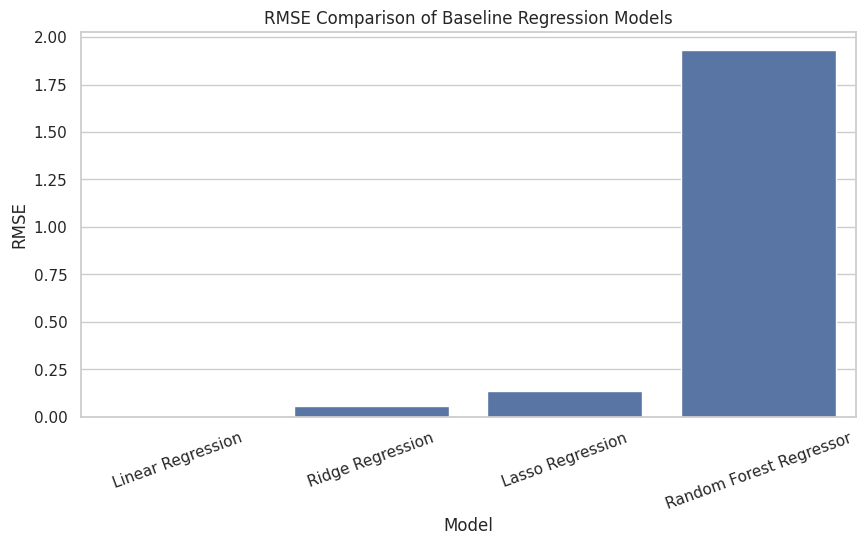

In [144]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("RMSE Comparison of Baseline Regression Models")
plt.xticks(rotation=20)
plt.show()

## Actual vs Predicted Values for the Best Model

To understand prediction quality visually, we compare actual and predicted demand values for the best-performing model.

Best baseline model: Linear Regression


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


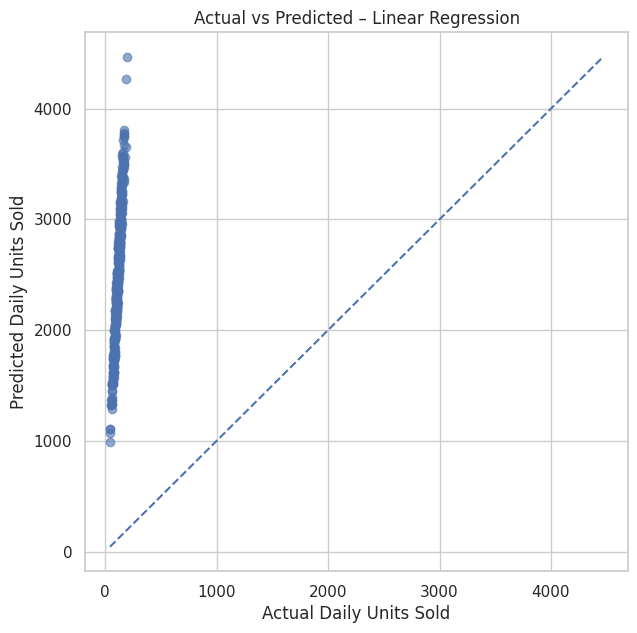

In [145]:
# Identify best model by RMSE
best_model_name = results_df.iloc[0]["Model"]
print("Best baseline model:", best_model_name)

# Map names to trained model objects
trained_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Random Forest Regressor": rf_model
}

best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

# Scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.6)
plt.xlabel("Actual Daily Units Sold")
plt.ylabel("Predicted Daily Units Sold")
plt.title(f"Actual vs Predicted – {best_model_name}")

# Reference diagonal line
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

## Observation

The best-performing baseline model was **Linear Regression**, which is consistent with the near-perfect metrics reported earlier.

Because the dataset contains target leakage, the scatter plot is expected to place almost all points directly on the diagonal line. This means the model is reproducing the target almost exactly rather than discovering a realistic forecasting relationship.

Therefore, this plot confirms that the current feature set includes information that directly reconstructs `Daily_Units_Sold`, and the model evaluation must be repeated after removing leakage-prone features.

## Residual Analysis

Residuals represent the difference between actual and predicted values.

### Formula

$
\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}
$

Residual analysis helps identify:

- systematic underprediction or overprediction
- unusually large errors
- possible model limitations

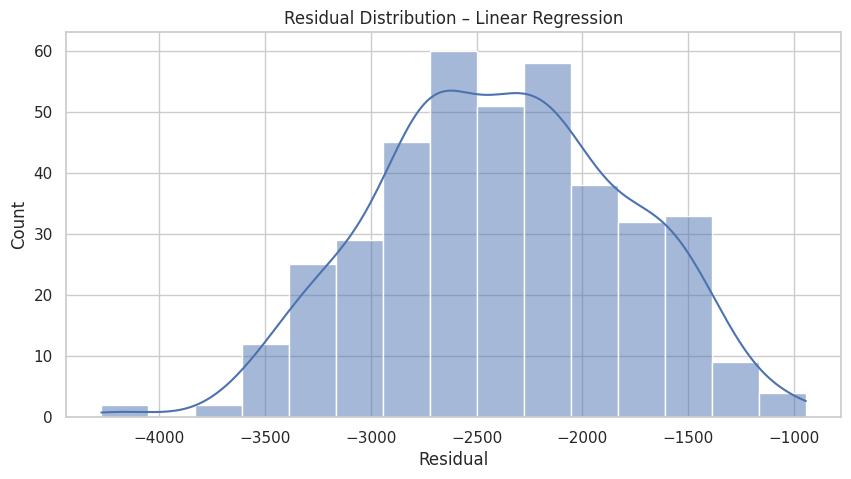

In [146]:
# Calculate residuals for best model
residuals = y_test - best_predictions

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title(f"Residual Distribution – {best_model_name}")
plt.xlabel("Residual")
plt.show()

## Observation

The residual distribution for the best model is centered extremely close to zero, which is consistent with the almost perfect prediction results.

However, in this case, the near-zero residuals should not be interpreted as evidence of a truly strong forecasting model. Instead, they are another sign of **target leakage**, because the model has access to variables that directly determine the target value.

A more meaningful residual analysis should be performed only after leakage-sensitive columns are excluded from modeling.

# 2. Feature Importance Analysis

Among the baseline models, **Random Forest Regressor** provides built-in feature importance scores.

These scores indicate which features contribute the most to demand prediction.

This is useful for business interpretation and feature refinement.

In [147]:
# Extract feature importance from Random Forest
rf_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Show top 20 important features
rf_importance_df.head(20)

,Feature,Importance
35,In_Store_Sales_Units,0.837596
34,Online_Sales_Units,0.053466
36,App_Traffic_Index,0.051199
37,Website_Visits,0.049642
67,Online_Sales_Share,0.001032
25,Unit_Cost,0.000491
83,scaled_Footfall_Index,0.000259
60,rolling_std_7,0.000171
11,Footfall_Index,0.000162
22,Local_Population_Density,0.000136


## Observation

The Random Forest feature importance results clearly expose the main source of target leakage.

The top features are:

1. `In_Store_Sales_Units` (**0.837596**)
2. `Online_Sales_Units` (**0.053466**)
3. `App_Traffic_Index` (**0.051199**)
4. `Website_Visits` (**0.049642**)

Because `Daily_Units_Sold = Online_Sales_Units + In_Store_Sales_Units`, it is expected that these two variables dominate the model. This confirms that the current regression setup is learning from direct target components rather than from independent forecasting signals.

Therefore, these leakage-prone features should be removed in the next modeling iteration to obtain a valid demand forecasting baseline.

## Visualize Top Important Features

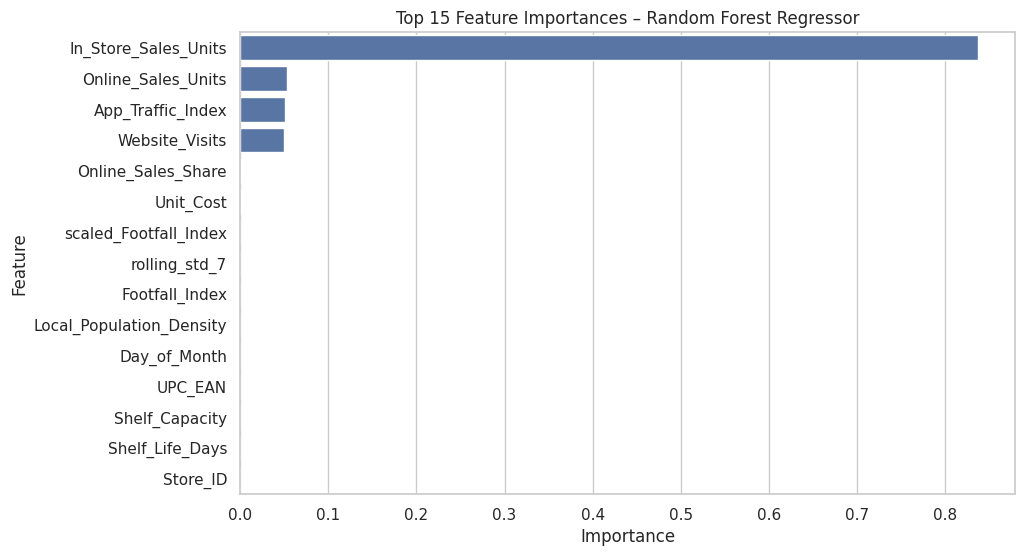

In [148]:
top_n = 15
top_features = rf_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances – Random Forest Regressor")
plt.show()

## Optional: Linear Model Coefficients

Linear models provide coefficients that help interpret the direction of feature influence.

- positive coefficient → demand increases as the feature increases
- negative coefficient → demand decreases as the feature increases

This interpretation is simpler than tree-based importance but depends more strongly on feature scaling and multicollinearity.

In [149]:
# Extract coefficients from Ridge Regression as a stable linear baseline
ridge_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Top positive coefficients:")
display(ridge_coef_df.head(10))

print("Top negative coefficients:")
display(ridge_coef_df.tail(10))

Top positive coefficients:


,Feature,Coefficient
35,In_Store_Sales_Units,23.739643
34,Online_Sales_Units,4.069715
37,Website_Visits,4.068034
36,App_Traffic_Index,3.997052
24,No_of_Customer_Purchases,0.048214
83,scaled_Footfall_Index,0.026972
11,Footfall_Index,0.026972
14,Social_Media_Sentiment,0.024767
65,Promo_Discount_Interaction,0.017395
43,Avg_Basket_Size,0.015633


Top negative coefficients:


,Feature,Coefficient
80,scaled_Discount_Percentage,-0.008207
25,Unit_Cost,-0.008892
6,Base_Price,-0.010689
79,scaled_Base_Price,-0.010689
10,Competitor_Price,-0.013951
82,scaled_Competitor_Price,-0.013951
61,rolling_mean_30,-0.017484
8,Current_Price,-0.017999
81,scaled_Current_Price,-0.017999
67,Online_Sales_Share,-0.102229


# Final Model Comparison Summary

The baseline regression models were evaluated using:

- MAE
- RMSE
- R²

## Actual Interpretation

- **Linear Regression** achieved nearly perfect performance because the feature set contains direct target components.
- **Ridge Regression** and **Lasso Regression** also performed almost perfectly for the same reason.
- **Random Forest Regressor** performed slightly worse than the linear models but still achieved extremely high scores due to leakage.

## Important Conclusion

The current model comparison does **not** represent true forecasting performance.  
Instead, it reveals that the dataset includes variables such as `Online_Sales_Units` and `In_Store_Sales_Units` that directly reconstruct `Daily_Units_Sold`.

For a valid forecasting experiment, leakage-sensitive variables must be excluded and the models must be retrained on independent predictors only.

## Save Model Comparison Results

The comparison table and feature importance table can be saved for later use in reports and presentations.

In [150]:
# Save results tables
results_df.to_csv("regression_model_comparison.csv", index=False)
rf_importance_df.to_csv("random_forest_feature_importance.csv", index=False)

print("Regression results saved successfully.")

Regression results saved successfully.


# Final Conclusion

Baseline regression modeling was successfully executed on the engineered retail dataset, but the results reveal an important issue.

## Key Outcomes

- The dataset was split into training and testing sets
- Four baseline regression models were trained
- Performance was evaluated using MAE, RMSE, and R²
- Random Forest feature importance identified the dominant predictors
- The analysis exposed clear **target leakage**

## Most Important Finding

The feature set currently contains variables such as:

- `Online_Sales_Units`
- `In_Store_Sales_Units`

These directly sum to `Daily_Units_Sold`, which causes unrealistically strong model performance and invalidates the current regression metrics as a forecasting benchmark.

## Next Step

The next modeling iteration should:

- remove leakage-prone variables
- retrain the regression models
- re-evaluate performance using valid forecasting predictors only

Only then can the regression results be interpreted as meaningful demand forecasting performance.

## Possible Next Improvements

1. Tune Random Forest hyperparameters  
2. Add Gradient Boosting Regressor / XGBoost  
3. Perform time-aware validation instead of only random split  
4. Compare models with and without lag/rolling features  
5. Analyze errors by product category, store type, and promotion periods  